<a href="https://colab.research.google.com/github/lorymasia/Boston-Dataset-Analisys/blob/main/Boston_Dataset_ML_Analisys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Esame Dataset Boston

### Un set di dati contenente valori immobiliari in 506 sobborghi di Boston.

- crim: tasso di criminalità pro capite per città.

- zn: proporzione di terreno residenziale zonato per lotti superiori a 25.000 piedi quadrati (2.322,58 metri quadrati).

- indus: proporzione di acri ad uso commerciale non al dettaglio per città.

- chas: variabile dummy del fiume Charles (= 1 se il tratto confina con il fiume; 0 altrimenti).

- nox: concentrazione di ossidi di azoto (parti per 10 milioni).

- rm: numero medio di stanze per abitazione.

- age: proporzione di unità abitate dal proprietario costruite prima del 1940.

- dis: media pesata delle distanze dai cinque centri occupazionali di Boston.

- rad: indice di accessibilità alle autostrade radiali.

- tax: aliquota fiscale di pieno valore per $10.000.

- ptratio: rapporto alunni-insegnanti per città.

- lstat: stato socioeconomico inferiore della popolazione (percentuale).

- medv: valore mediano delle abitazioni occupate dai proprietari in migliaia di dollari.

## Importazione delle librerie e dataset

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import norm, gaussian_kde, skew
from itertools import combinations

from ISLP import load_data

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, train_test_split, cross_validate, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

RANDOM_STATE = 42

In [ ]:
df = load_data('Boston')

## Dichiarazione funzioni

In [ ]:
def visualizza_distr(distr, bins=30):
    kde = gaussian_kde(distr)
    x = np.linspace(distr.min(), distr.max(), 200)

    media_distr    = np.mean(distr)
    mediana_distr  = np.median(distr)
    asimmetria_distr = skew(distr)

    print(f"Media: {media_distr:.5f}, Mediana: {mediana_distr:.5f}, Asimmetria: {asimmetria_distr:.5f}")

    kde_y = kde(x)

    fig = go.Figure()

    fig.add_trace(go.Histogram(
        x=distr,
        nbinsx=bins,
        histnorm='probability density',
        name='Distribuzione',
        marker_color='#6CB4E4',
        marker_line=dict(color='white', width=0.5),
        opacity=0.75,
    ))

    fig.add_trace(go.Scatter(
        x=x, y=kde_y,
        mode='lines',
        name='KDE',
        line=dict(color='#E05C4B', width=2.5),
    ))

    fig.add_vline(
        x=media_distr,
        line_color='gold', line_width=2,
        annotation_text=f'Media: {media_distr:.5f}',
        annotation_position='top right',
        annotation_font=dict(color='gold', size=11),
    )

    fig.add_vline(
        x=mediana_distr,
        line_color='#2E8B57', line_width=2, line_dash='dash',
        annotation_text=f'Mediana: {mediana_distr:.5f}',
        annotation_position='bottom right',
        annotation_font=dict(color='#2E8B57', size=11),
    )

    fig.update_layout(
        title={'text': f'Distribuzione<br>'
                       f"<span style='font-size:15px;font-weight:normal'>"
                       f'Asimmetria: {asimmetria_distr:.5f}</span>'},
        legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
    )
    fig.update_xaxes(title_text='Valori di lstat')
    fig.update_yaxes(title_text='Densità di medv')

    fig.show()

def print_confusion_and_report(y_true01, y_pred01, title: str = "", thresh: float = None):
    cm = confusion_matrix(y_true01, y_pred01, labels=[0, 1])

    thresh_label = f"{thresh:.1f}" if thresh is not None else "median"
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            f"medv ≤ {thresh_label}",
            f"medv > {thresh_label}",
        ]
    )
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap="Blues", ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.show()

    print("\n" + "-" * 80)
    print(title)
    print("Confusion matrix (righe=true, colonne=pred) [0,1]:\n", cm)
    print("\nInterpretazione rapida:")
    print(f"TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")
    print("\nClassification report:\n", classification_report(y_true01, y_pred01, digits=3))


def plot_roc_curves(curves, title: str):
    plt.figure(figsize=(7, 6))
    for c in curves:
        fpr, tpr, _ = roc_curve(c["y_true"], c["y_score"])
        auc = roc_auc_score(c["y_true"], c["y_score"])
        plt.plot(fpr, tpr, label=f"{c['name']} (AUC={auc:.3f})")

    # diagonale: modello casuale
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()


def plot_precision_recall(y_true01, y_score, title: str):
    precision, recall, _ = precision_recall_curve(y_true01, y_score)
    ap = average_precision_score(y_true01, y_score)

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"AP={ap:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()


## 1. Visualizzare le informazioni base

In [ ]:
df.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


## 2. Verificare la presenza di valori mancanti.

In [ ]:
df.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
lstat      0
medv       0
dtype: int64

## 3. Calcolare le statistiche descrittive principali.

In [ ]:
df.describe().round(2)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,37.97,50.00


## 4. Costruire:
- __Istogramma di medv con le altre features più rilevanti__ <br>
- __Matrice di correlazione__

In [ ]:
corr_medv = df.corr()['medv'].drop('medv').abs().sort_values(ascending=False)
top_features = corr_medv.head(5).index.tolist()
print("Top 5 feature correlate con medv:", top_features)

cols_to_plot = ['medv'] + top_features
n_cols = 3
n_rows = 2

subplot_titles = [f'Distribuzione di {col}' for col in cols_to_plot]

subplot_titles += [''] * (n_rows * n_cols - len(cols_to_plot))

fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=subplot_titles)

for i, col in enumerate(cols_to_plot):
    row = i // n_cols + 1
    col_idx = i % n_cols + 1

    fig.add_trace(
        go.Histogram(
            x=df[col],
            nbinsx=30,
            name=col,
            marker_color='#6CB4E4',
            marker_line=dict(color='white', width=0.5),
            opacity=0.85,
            showlegend=False,
        ),
        row=row, col=col_idx
    )

    fig.update_xaxes(title_text=col,       row=row, col=col_idx)
    fig.update_yaxes(title_text='Frequenza', row=row, col=col_idx,
                     showgrid=True, gridcolor='rgba(150,150,150,0.3)',
                     griddash='dash')

fig.update_layout(
    title={'text': "Istogrammi: medv e le Feature più Correlate"},
    height=700,
    width=1300,
)

fig.show()

Top 5 feature correlate con medv: ['lstat', 'rm', 'ptratio', 'indus', 'tax']


In [ ]:
visualizza_distr(df.medv, bins=30)

Media: 22.53281, Mediana: 21.20000, Asimmetria: 1.10481


__Come possiamo notare nel grafico, la distribuzione di medv è asimmetrica a destra, con una coda lunga verso valori più alti. La maggior parte dei valori di medv si concentra tra 15 e 30, con alcuni outlier che raggiungono valori superiori a 50.__

In [ ]:
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = corr.copy().astype(object)
corr_masked[mask] = np.nan  # celle mascherate → NaN → trasparenti

labels = corr.columns.tolist()

annot_text = np.where(
    mask,
    '',
    corr.round(2).astype(str)
)

fig = go.Figure(go.Heatmap(
    z=corr_masked.values.astype(float),
    x=labels,
    y=labels,
    colorscale='RdBu_r',
    zmid=0,
    text=annot_text,
    texttemplate='%{text}',
    textfont=dict(size=8),
    xgap=1,
    ygap=1,
    colorbar=dict(title='r'),
))

fig.update_layout(
    title={'text': 'Matrice di Correlazione – Dataset Boston'},
    height=650,
    width=700,
    yaxis=dict(autorange='reversed', showgrid=False),
    xaxis=dict(showgrid=False),
    plot_bgcolor='white',
)

fig.show()


### Dalla matrice di correlazione, possiamo osservare che le variabili più correlate con medv sono:
- __LSTAT (percentuale di popolazione con basso status socioeconomico)con una correlazione di -0.74, indicando una forte correlazione negativa.__

- __RM (numero medio di stanze per abitazione) con una correlazione di 0.70, indicando una forte correlazione positiva.__

- __PTRATIO (rapporto alunni-insegnanti) con una correlazione di -0.51, indicando una correlazione negativa moderata.__

- __INDUS (percentuale di acri di attività commerciale non al dettaglio per città) con una correlazione di -0.48, indicando una correlazione negativa moderata.__

- __NOX (concentrazione di ossidi di azoto) con una correlazione di -0.43, indicando una correlazione negativa moderata.__

__Come abbiamo visto nella matrice di correlazione le feature più correlate con medv sono LSTAT, RM, PTRATIO, INDUS e NOX. LSTAT dimostra come un aumento della percentuale di popolazione con basso status socioeconomico è associato a una diminuzione del valore medv. RM dimostra che un aumento del numero medio di stanze per abitazione è associato a un aumento del valore medv. PTRATIO, INDUS e NOX indicando che un aumento di queste variabili è associato a una diminuzione del valore medv.__

# Parte 2 - Regressione Lineare Semplice

### Esercizio 2 – Regressione Lineare Semplice (medv ~ lstat)


In [ ]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {train_df.shape[0]} righe  |  Test: {test_df.shape[0]} righe")

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred)
    }

Train: 404 righe  |  Test: 102 righe


In [ ]:
X_train = train_df[["lstat"]]
y_train = train_df["medv"]

X_test = test_df[["lstat"]]
y_test = test_df["medv"]

In [ ]:
models = Pipeline(steps=[
    ("model", LinearRegression())
])

models.fit(X_train, y_train)

coef = models.named_steps["model"].coef_[0]
intercept = models.named_steps["model"].intercept_

print("Intercetta:", intercept)
print("Coefficiente (lstat):", coef)

Intercetta: 34.83694982031851
Coefficiente (lstat): -0.966530901950353


__Possiamo notare che LSTAT ha un coefficiente negtativo, andando quindi a confermare la correlazione negativa osservata in precedenza. In particolare, il coefficiente di LSTAT è -0.96, indicando che per ogni aumento dell'1% nella percentuale di popolazione con basso status socioeconomico, il valore medv diminuisce in media di 0.96 migliaia di dollari.__

In [ ]:
pred_train = models.predict(X_train)
train_metrics = regression_metrics(y_train, pred_train)

pred_test = models.predict(X_test)
test_metrics = regression_metrics(y_test, pred_test)

display(pd.DataFrame([
    {"split": "train", **train_metrics},
    {"split": "test", **test_metrics},
]))

,split,R2,MSE,RMSE
0,train,0.542318,39.760387,6.305584
1,test,0.542918,33.519549,5.789607


__Dalla regressione possiamo notare come il modello spiega circa il 54% della variabilità di medv, indicando che LSTAT è una variabile predittiva significativa per il valore medv.__

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['lstat'],
    y=df['medv'],
    mode='markers',
    name='Dati reali',
    marker=dict(opacity=0.5),
))

sorted_idx = X_test['lstat'].argsort()
fig.add_trace(go.Scatter(
    x=X_test['lstat'].iloc[sorted_idx],
    y=pred_test[sorted_idx],
    mode='lines',
    name='Regressione',
    line=dict(color='#E05C4B', width=2),
))

fig.update_layout(
    title={'text': 'Regressione Lineare Semplice'},
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
)
fig.update_xaxes(title_text='lstat')
fig.update_yaxes(title_text='medv')

fig.show()


# K-Fold Validation

In [ ]:
X = train_df[["lstat"]]
y = train_df["medv"]

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(models, X, y, cv=kf, scoring="r2")
cv_mse = -cross_val_score(models, X, y, cv=kf, scoring="neg_mean_squared_error")
cv_rmse = np.sqrt(cv_mse)

print("CV R2 (mean±std):", cv_r2.mean(), "±", cv_r2.std())
print("CV MSE (mean±std):", cv_mse.mean(), "±", cv_mse.std())
print("CV RMSE (mean±std):", cv_rmse.mean(), "±", cv_rmse.std())

CV R2 (mean±std): 0.5428147541494676 ± 0.05719864951557378
CV MSE (mean±std): 40.10129463616482 ± 10.851809110802915
CV RMSE (mean±std): 6.269623213431246 ± 0.8905725112358205


In [ ]:
folds = [f"Fold {i+1}" for i in range(5)]

fig = make_subplots(rows=1, cols=2, subplot_titles=("R² per Fold", "MSE per Fold"))

fig = make_subplots(rows=1, cols=3, subplot_titles=("R² per Fold", "MSE per Fold", "RMSE per Fold"))

for col_idx, (values, name, color, ylabel) in enumerate([
    (cv_r2,   'R²',   '#6CB4E4', 'R²'),
    (cv_mse,  'MSE',  '#F4A261', 'MSE'),
    (cv_rmse, 'RMSE', '#2E8B57', 'RMSE'),
], start=1):
    fig.add_trace(go.Bar(
        x=folds, y=values,
        name=name,
        marker_color=color,
        text=values.round(4),
        textposition='outside',
    ), row=1, col=col_idx)

    fig.add_hline(
        y=values.mean(), line_dash='dash', line_color='#E05C4B', line_width=2,
        annotation_text=f"μ={values.mean():.4f} ± {values.std():.4f}",
        annotation_position='bottom right',
        annotation_font=dict(color='#E05C4B', size=11),
        row=1, col=col_idx
    )

    fig.update_xaxes(title_text='Fold',  row=1, col=col_idx)
    fig.update_yaxes(title_text=ylabel,  row=1, col=col_idx)

fig.update_layout(
    title={'text': '5-Fold Cross Validation — R², MSE e RMSE per Fold'},
    showlegend=False,
    height=450,
    width=1100,
)

fig.show()


__Nella K-Fold Cross Validation possiamo notare che l'R² media si aggira a un 0.54, confermando la bontà del modello. Da notare che l'R² può variare tra i diversi fold, indicando che il modello potrebbe essere più o meno performante a seconda dei dati di addestramento e test utilizzati.__

### ESERCIZIO 3 – Regressione Lineare Semplice (medv ~ rm)

In [ ]:
X = train_df[["rm"]]
y = train_df["medv"]

models.fit(X, y)

coef = models.named_steps["model"].coef_[0]
intercept = models.named_steps["model"].intercept_

print("Intercetta:", intercept)
print("Coefficiente (rm):", coef)

Intercetta: -36.24631889813792
Coefficiente (rm): 9.348301406497722


__Cambiando feature da LSTAT a RM, possiamo notare che il coefficiente di RM è 9.34, indicando che per ogni aumento di una stanza in media per abitazione, il valore medv aumenta in media di 9.34 migliaia di dollari.__

In [ ]:
X_train = train_df[["rm"]]
y_train = train_df["medv"]

X_test = test_df[["rm"]]
y_test = test_df["medv"]

In [ ]:
pred_train = models.predict(X_train)
train_metrics = regression_metrics(y_train, pred_train)

pred_test = models.predict(X_test)
test_metrics = regression_metrics(y_test, pred_test)

display(pd.DataFrame([
    {"split": "train", **train_metrics},
    {"split": "test", **test_metrics},
]))

,split,R2,MSE,RMSE
0,train,0.505066,42.996616,6.557180
1,test,0.370757,46.144775,6.792995


In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['rm'],
    y=df['medv'],
    mode='markers',
    name='Dati reali',
    marker=dict(opacity=0.5),
))

sorted_idx = X_test['rm'].argsort()
fig.add_trace(go.Scatter(
    x=X_test['rm'].iloc[sorted_idx],
    y=pred_test[sorted_idx],
    mode='lines',
    name='Regressione',
    line=dict(color='#E05C4B', width=2),
))

fig.update_layout(
    title={'text': 'Regressione Lineare Semplice'},
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
)
fig.update_xaxes(title_text='rm')
fig.update_yaxes(title_text='medv')

fig.show()


## K-Fold Validation

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(models, X, y, cv=kf, scoring="r2")
cv_mse = -cross_val_score(models, X, y, cv=kf, scoring="neg_mean_squared_error")
cv_rmse = np.sqrt(cv_mse)

print("CV R2 (mean±std):", cv_r2.mean(), "±", cv_r2.std())
print("CV MSE (mean±std):", cv_mse.mean(), "±", cv_mse.std())
print("CV RMSE (mean±std):", cv_rmse.mean(), "±", cv_rmse.std())

CV R2 (mean±std): 0.47923862655092575 ± 0.1327705989242
CV MSE (mean±std): 43.27844087241889 ± 7.697301837059179
CV RMSE (mean±std): 6.553912847143449 ± 0.5697958094501314


In [ ]:
folds = [f"Fold {i+1}" for i in range(5)]

fig = make_subplots(rows=1, cols=2, subplot_titles=("R² per Fold", "MSE per Fold"))

fig = make_subplots(rows=1, cols=3, subplot_titles=("R² per Fold", "MSE per Fold", "RMSE per Fold"))

for col_idx, (values, name, color, ylabel) in enumerate([
    (cv_r2,   'R²',   '#6CB4E4', 'R²'),
    (cv_mse,  'MSE',  '#F4A261', 'MSE'),
    (cv_rmse, 'RMSE', '#2E8B57', 'RMSE'),
], start=1):
    fig.add_trace(go.Bar(
        x=folds, y=values,
        name=name,
        marker_color=color,
        text=values.round(4),
        textposition='outside',
    ), row=1, col=col_idx)

    fig.add_hline(
        y=values.mean(), line_dash='dash', line_color='#E05C4B', line_width=2,
        annotation_text=f"μ={values.mean():.4f} ± {values.std():.4f}",
        annotation_position='bottom right',
        annotation_font=dict(color='#E05C4B', size=11),
        row=1, col=col_idx
    )

    fig.update_xaxes(title_text='Fold',  row=1, col=col_idx)
    fig.update_yaxes(title_text=ylabel,  row=1, col=col_idx)

fig.update_layout(
    title={'text': '5-Fold Cross Validation — R², MSE e RMSE per Fold'},
    showlegend=False,
    height=450,
    width=1100,
)

fig.show()


__Andando ad eseguire una K-Fold possiamo notare un R2 medio di 0.47, indicando che il modello con la feature RM spiega circa il 47% della variabilità di medv, con un errore medio di circa 43 migliaia di dollari.__

### ESERCIZIO 4 – Regressione Lineare Multipla

In [ ]:
features = ["lstat", "rm", "ptratio", "nox"]
target   = "medv"

X_train_m = train_df[features]
X_test_m = test_df[features]

y_train_m = train_df[target]
y_test_m = test_df[target]

In [ ]:
models.fit(X_train_m, y_train_m)

for feat, c in zip(features, models.named_steps['model'].coef_):
    print(f"Coeff {feat}: {c:.4f}")
    intercept = models.named_steps["model"].intercept_
print("Intercetta:", intercept)


Coeff lstat: -0.5487
Coeff rm: 4.9589
Coeff ptratio: -0.8713
Coeff nox: -1.6631
Intercetta: 15.197795770392993


__Qua possiamo notare come il coefficiente della features aggiunte abbia quasi sempre il segno negativo, andando ad indicare come all'aumentare di queste variabili sia associata una diminuzione del valore medv, ad eccezione di RM che ha un coefficiente positivo, indicando che un aumento del numero medio di stanze per abitazione è associato a un aumento del valore medv.__

In [ ]:
pred_train = models.predict(X_train_m)
train_metrics = regression_metrics(y_train_m, pred_train)

pred_test = models.predict(X_test_m)
test_metrics = regression_metrics(y_test_m, pred_test)

display(pd.DataFrame([
    {"split": "train", **train_metrics},
    {"split": "test", **test_metrics},
]))

,split,R2,MSE,RMSE
0,train,0.686738,27.214157,5.216719
1,test,0.632109,26.978805,5.194113


In [ ]:
fig = go.Figure()

# Punti del test set
fig.add_trace(go.Scatter(
    x=pred_test,
    y=y_test_m,
    mode='markers',
    name='Test set',
    marker=dict(color='#6CB4E4', opacity=0.6),
))

# Punti del train set
fig.add_trace(go.Scatter(
    x=pred_train,
    y=y_train_m,
    mode='markers',
    name='Train set',
    marker=dict(color='#2E8B57', opacity=0.4),
))

# Diagonale perfetta (predicted == actual)
min_val = min(pred_test.min(), y_test_m.min())
max_val = max(pred_test.max(), y_test_m.max())
fig.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    name='Predizione perfetta',
    line=dict(color='#E05C4B', dash='dash', width=2),
))

fig.update_layout(
    title={'text': 'Regressione Multipla — Predicted vs Actual'},
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
    height=450, width=1100,
)
fig.update_xaxes(title_text='Valori Predetti')
fig.update_yaxes(title_text='Valori Reali')
fig.show()


## K-Fold Validation

In [ ]:
kf   = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

cv = cross_validate(
    pipe, X_train_m, y_train_m,
    cv=kf,
    scoring=["r2", "neg_mean_squared_error"],
    return_train_score=True
)

fold_df = pd.DataFrame({
    "fold":       [f"Fold {i+1}" for i in range(kf.get_n_splits())],
    "r2_train":   cv["train_r2"],
    "r2_val":     cv["test_r2"],
    "mse_train":  -cv["train_neg_mean_squared_error"],
    "mse_val":    -cv["test_neg_mean_squared_error"],
    "rmse_train": np.sqrt(-cv["train_neg_mean_squared_error"]),
    "rmse_val":   np.sqrt(-cv["test_neg_mean_squared_error"]),
})

fold_df.loc[len(fold_df)] = {
    "fold":       "Media",
    "r2_train":   fold_df["r2_train"].mean(),
    "r2_val":     fold_df["r2_val"].mean(),
    "mse_train":  fold_df["mse_train"].mean(),
    "mse_val":    fold_df["mse_val"].mean(),
    "rmse_train": fold_df["rmse_train"].mean(),
    "rmse_val":   fold_df["rmse_val"].mean(),
}

display(fold_df)


,fold,r2_train,r2_val,mse_train,mse_val,rmse_train,rmse_val
0,Fold 1,0.699408,0.616867,27.302278,27.240689,5.225158,5.219261
1,Fold 2,0.674837,0.714188,27.293636,28.071154,5.224331,5.298222
2,Fold 3,0.729627,0.500627,23.340012,44.365813,4.831150,6.660767
3,Fold 4,0.663879,0.748398,27.407154,26.908327,5.235184,5.187324
4,Fold 5,0.672974,0.750492,29.939378,16.534316,5.471689,4.066241
5,Media,0.688145,0.666115,27.056492,28.624060,5.197503,5.286363


In [ ]:
fig = make_subplots(rows=1, cols=3, subplot_titles=("R² per Fold", "MSE per Fold", "RMSE per Fold"))

for col_idx, (train_col, val_col, ylabel) in enumerate([
    ("r2_train",   "r2_val",   "R²"),
    ("mse_train",  "mse_val",  "MSE"),
    ("rmse_train", "rmse_val", "RMSE"),
], start=1):

    fig.add_trace(go.Bar(
        x=fold_df["fold"], y=fold_df[train_col],
        name="Train",
        marker_color='#6CB4E4',
        text=fold_df[train_col].round(3),
        textposition='outside',
        offsetgroup=0,
        showlegend=(col_idx == 1),
    ), row=1, col=col_idx)

    fig.add_trace(go.Bar(
        x=fold_df["fold"], y=fold_df[val_col],
        name="Validation",
        marker_color='#E05C4B',
        text=fold_df[val_col].round(3),
        textposition='outside',
        offsetgroup=1,
        showlegend=(col_idx == 1),
    ), row=1, col=col_idx)

    fig.add_hline(
        y=fold_df[val_col].mean(),
        line_dash='dash', line_color='#E05C4B', line_width=1.5,
        annotation_text=f"μ val={fold_df[val_col].mean():.3f}",
        annotation_position="bottom right",
        annotation_font=dict(color='#E05C4B', size=11),
        row=1, col=col_idx
    )

    fig.add_hline(
        y=fold_df[train_col].mean(),
        line_dash='dash', line_color='#6CB4E4', line_width=1.5,
        annotation_text=f"μ train={fold_df[train_col].mean():.3f}",
        annotation_position="top right",
        annotation_font=dict(color='#6CB4E4', size=11),
        row=1, col=col_idx
    )

    fig.update_xaxes(title_text="Fold", row=1, col=col_idx)
    fig.update_yaxes(title_text=ylabel, row=1, col=col_idx)

fig.update_layout(
    title={"text": "5-Fold CV — Performance per Fold (Train vs Validation)"},
    barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=1.08, xanchor='center', x=0.5),
    height=480, width=1500,
)
fig.show()


__In questa parte della regressione si é andati ad aumentare la complessità del modello, passando da una regressione lineare semplice ad una multipla, includendo più variabili predittive. L'obiettivo è stato quello di valutare se l'inclusione di più variabili potesse migliorare la capacità predittiva del modello rispetto alla regressione semplice. Per valutare le performance del modello ho attuato una K-Fold Cross Validation, ottenendo un R² medio di 0.68, indicando che il modello con più variabili spiega circa il 68% della variabilità di medv, con un errore medio di circa 27 migliaia di dollari__

## Recap Regressione

__Da questo esecrizio di regressione abbiamo potuto notare come l'inclusione di più variabili predittive abbia migliorato la capacità del modello di spiegare la variabilità di medv, passando da un R² di 0.54 con la regressione semplice a un R² di 0.68 con la regressione multipla. Questo suggerisce che le variabili aggiuntive (RM, PTRATIO e NOX) forniscono informazioni preziose per prevedere il valore medv, oltre a LSTAT.__

# PARTE 3 – CLASSIFICAZIONE

In [ ]:
allvars = ["lstat", "rm", "ptratio", "nox"]
X = df[allvars]

y_cont = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cont,
    test_size=0.2,
    random_state=RANDOM_STATE
)

threshold = y_train.median()

# Target binario costruito usando la soglia del train
y_train = (y_train > threshold).astype(int)
y_test = (y_test > threshold).astype(int)

In [ ]:
models = {
    "Logistic": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(random_state=RANDOM_STATE)),
        ]
    ),
    "LDA": LDA(),
    "QDA": QDA(),
    "KNN (K=5, scaled)": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=5)),
        ]
    ),
}

          CONFRONTO MODELLI (Test Set)
          Modello  Accuracy  F1-Score  AUC-ROC  Avg Prec.
         Logistic     0.843     0.805    0.932      0.925
              LDA     0.824     0.780    0.919      0.899
              QDA     0.804     0.762    0.928      0.904
KNN (K=5, scaled)     0.843     0.805    0.921      0.884

MODELLO MIGLIORE: Logistic  (AUC = 0.932)


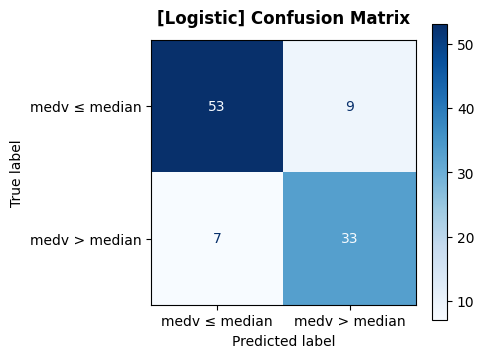


--------------------------------------------------------------------------------
[Logistic] Confusion Matrix
Confusion matrix (righe=true, colonne=pred) [0,1]:
 [[53  9]
 [ 7 33]]

Interpretazione rapida:
TN=53  FP=9  FN=7  TP=33

Classification report:
               precision    recall  f1-score   support

           0      0.883     0.855     0.869        62
           1      0.786     0.825     0.805        40

    accuracy                          0.843       102
   macro avg      0.835     0.840     0.837       102
weighted avg      0.845     0.843     0.844       102



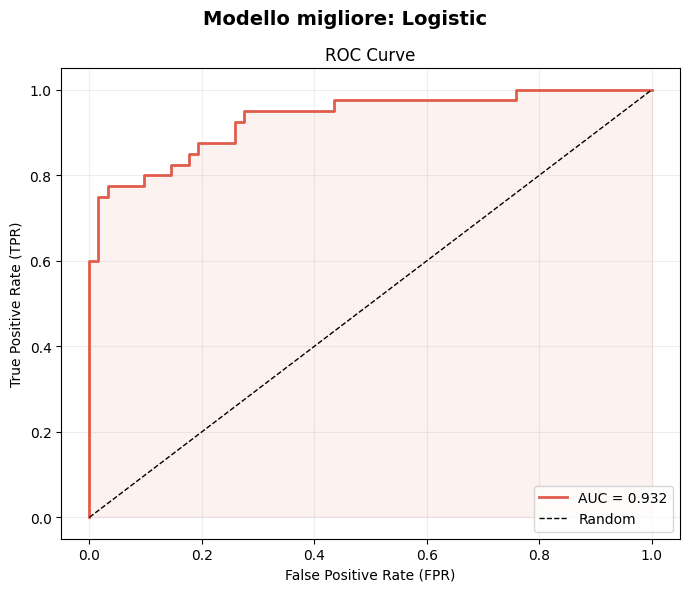

In [ ]:
results = []
fitted  = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_score)
    ap   = average_precision_score(y_test, y_score)

    results.append({
        "Modello":   name,
        "Accuracy":  round(acc,  3),
        "F1-Score":  round(f1,   3),
        "AUC-ROC":   round(auc,  3),
        "Avg Prec.": round(ap,   3),
        "_y_score":  y_score,
        "_y_pred":   y_pred,
    })

df_results = pd.DataFrame(results)
df_display = df_results.drop(columns=["_y_score", "_y_pred"])
print("=" * 60)
print("          CONFRONTO MODELLI (Test Set)")
print("=" * 60)
print(df_display.to_string(index=False))

best_row   = df_results.loc[df_results["AUC-ROC"].idxmax()]
best_name  = best_row["Modello"]
best_pred  = best_row["_y_pred"]
best_score = best_row["_y_score"]

print("\n" + "=" * 60)
print(f"MODELLO MIGLIORE: {best_name}  (AUC = {best_row['AUC-ROC']})")
print("=" * 60)

print_confusion_and_report(y_test, best_pred, title=f"[{best_name}] Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, best_score)
auc_val = roc_auc_score(y_test, best_score)

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle(f"Modello migliore: {best_name}", fontsize=14, fontweight="bold")

ax.plot(fpr, tpr, color="#E05C4B", lw=2, label=f"AUC = {auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.fill_between(fpr, tpr, alpha=0.08, color="#E05C4B")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Recap Classificazione

__Nella classificazione ho deciso prima di creare un target binario, che assume il valore di 1 se medv è maggiore della mediana e 0 altrimenti. Successivamente, ho addestrato un modello di classificazione utilizzando le stesse variabili predittive utilizzate nella regressione multipla (LSTAT, RM, PTRATIO e NOX) per prevedere se un'abitazione ha un prezzo alto (1) o basso (0). Ho valutato le performance di vari modelli partendo dalla Logistic Regression, LDA, QDA e KNN, ottenendo risultati simili tra i modelli, con un'accuratezza media tra i veri modelli che si aggira a circa 0.85, indicando che il modello è in grado di classificare correttamente circa l'85% delle abitazioni come ad alto o basso prezzo__

__Possiamo notare anche come la curva ROC della Logistic Regression che poi é stato il modello con le performance migliori, abbia un AUC di circa 0.93, indicando che il modello ha una buona capacità di discriminazione tra le classi, riuscendo a distinguere efficacemente tra abitazioni ad alto e basso prezzo__

# PARTE 4 – CLUSTERING (DBSCAN)

In [ ]:
cluster_features = ["lstat", "rm", "crim", "nox", "dis", "age"]

df_cluster = df[cluster_features].copy()

In [ ]:
X_cluster = StandardScaler().fit_transform(df_cluster)

In [ ]:
# Griglia di parametri da confrontare
eps_list = [0.5, 0.7, 0.9, 1.1, 1.3]
min_samples_list = [5, 8, 10, 15, 20]

rows = []
models = {}

for eps in eps_list:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_cluster)

        n_noise = np.sum(labels == -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        rows.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": int(n_noise),
            "noise_%": float(n_noise/len(labels))*100
        })
        models[(eps, ms)] = labels

results_dbscan = pd.DataFrame(rows).sort_values(["n_clusters", "noise_%"])
display(results_dbscan)


,eps,min_samples,n_clusters,n_noise,noise_%
3,0.5,15,0,506,100.000000
4,0.5,20,0,506,100.000000
20,1.3,5,1,16,3.162055
21,1.3,8,1,21,4.150198
15,1.1,5,1,24,4.743083
22,1.3,10,1,29,5.731225
23,1.3,15,1,39,7.707510
16,1.1,8,1,43,8.498024
24,1.3,20,1,45,8.893281
17,1.1,10,1,52,10.276680


,eps,min_samples,n_clusters,n_noise,noise_%
10,0.9,5,3,52,10.27668


Best DBSCAN params: 0.9 5
Clusters: 3 | Noise points: 52


,lstat,rm,crim,nox,dis,age
cluster,,,,,,
0,11.553701,6.363152,2.003288,0.533128,4.046315,65.369885
1,20.003571,5.493643,2.400789,0.871000,1.556164,95.614286
2,3.994000,8.241600,1.298932,0.621800,2.067620,93.340000


cluster
-1     52
 0    435
 1     14
 2      5
Name: count, dtype: int64

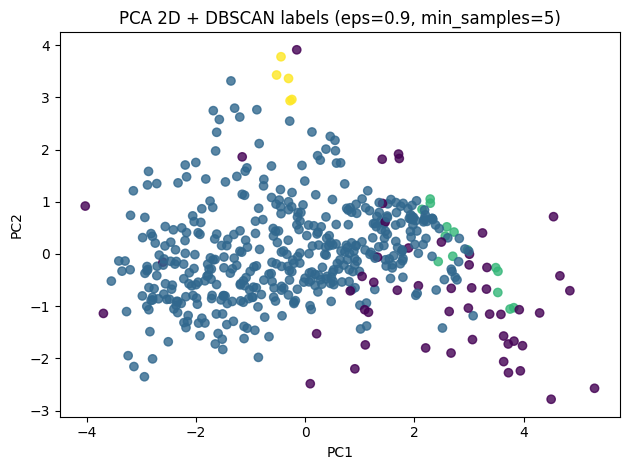

,noise_mean,clustered_mean
age,85.725000,66.610573
lstat,20.703269,11.731013
crim,17.632829,2.007788
rm,5.652596,6.357026
dis,2.461925,3.947735
nox,0.643502,0.544523
cluster,-1.000000,0.052863


In [ ]:
cand = results_dbscan[(results_dbscan["n_clusters"] >= 3)].copy()
best_row = cand.sort_values("n_noise", ascending=True).head(1)
display(best_row)

best_eps = float(best_row["eps"].iloc[0])
best_ms = int(best_row["min_samples"].iloc[0])
labels_best = models[(best_eps, best_ms)]

print("Best DBSCAN params:", best_eps, best_ms)
print("Clusters:", len(set(labels_best)) - (1 if -1 in labels_best else 0),
      "| Noise points:", int(np.sum(labels_best == -1)))

df_labels = df_cluster.copy()
df_labels["cluster"] = labels_best

profile = df_labels[df_labels["cluster"] != -1].groupby("cluster").mean(numeric_only=True)
display(profile)


counts = df_labels["cluster"].value_counts().sort_index()
display(counts)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_cluster)

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_best, alpha=0.8)
plt.title(f"PCA 2D + DBSCAN labels (eps={best_eps}, min_samples={best_ms})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

noise_stats = df_labels[df_labels["cluster"] == -1].mean(numeric_only=True)
non_noise_stats = df_labels[df_labels["cluster"] != -1].mean(numeric_only=True)
display(pd.DataFrame({"noise_mean": noise_stats, "clustered_mean": non_noise_stats}).sort_values("noise_mean", ascending=False))


## Recap Clustering

__Nella DBSCAN ho deciso di aggiungere un paio di features in piú dm, age e crim, come possiamo notare dal grafico e dai valori ottenuti per feature, notiamo come nel cluster siamo stati separati i quartieri con alto tasso di criminalitá, e quelli con un alto numero di abitazioni costruite prima del 1940, andando quindi a creare dei cluster che rappresentano quartieri con caratteristiche simili in termini di criminalitá e etá delle abitazioni. Questo ci permette di identificare aree della città che potrebbero avere esigenze specifiche in termini di sicurezza o ristrutturazione edilizia.__